# Tour-de-France-Effect — a quantitative teardown 🔬
### One-sample-*t* on the window return · a raw-vs-abnormal decomposition · a random-window placebo · the event anatomy · the 2020 race-vs-calendar probe · a 20-seed synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![France--specific%3F: Not_supported](https://img.shields.io/badge/France--specific%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **French equities get a feel-good seasonal during the July Tour de France** — has no published academic anchor of its own; it borrows its mechanism from Edmans, García & Norli (2007), a real elimination-shock effect for football World Cups, and stretches it onto a three-week calendar window that happens to sit inside the *"Sell in May"* summer-weakness season (Bouman & Jacobsen 2002). The job here is to measure it honestly and, crucially, to separate any *French* effect from ordinary pan-European summer beta.

> ⚠️ **Data note.** `EWQ` (France, total-return) + `^FCHI` (CAC 40, **price-only**) + `VGK` (Europe, total-return), yfinance, 1990-03-01→2026-06-30. 30 Tours hardcoded 1996→2025; all 30 EWQ-covered, **21** (2005→) also VGK-covered for the abnormal test. Calendar-known window → **no information lag** (dates public a year ahead). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `bf542dd5cb07`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from tour_de_france_effect import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_real()
    EV = st.build_event_table(PRICES, cost_bps=5.0)
    INC = EV[EV["included"]]
    SUB = INC[INC["has_ar"]]                        # 2005+, VGK coverage (abnormal test)
else:
    PRICES = EV = INC = SUB = None
print("real cache present:", HAVE_REAL, "| editions:", len(data.EVENTS),
      "| resolved:", (0 if INC is None else len(INC)),
      "| with abnormal:", (0 if SUB is None else len(SUB)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_editions': 30, 'n_included': 30, 'n_ar': 21, 'win_min': 15, 'win_max': 16, 'win_mean': 15.5, 'fp': 'bf542dd5cb07', 'raw_mean': -0.347, 'raw_t': -0.371, 'raw_hit': 13, 'raw_n': 30, 'raw_lo': 27.4, 'raw_hi': 60.8, 'raw_net_mean': -0.447, 'raw_net_t': -0.478, 'cac_mean': -0.325, 'cac_t': -0.376, 'cac_hit': 18, 'cac_n': 30, 'ewq_sub_mean': 0.476, 'ewq_sub_t': 0.416, 'vgk_mean': 0.681, 'vgk_t': 0.66, 'ar_mean': -0.205, 'ar_t': -0.777, 'ar_hit': 9, 'ar_n': 21, 'ar_lo': 24.5, 'ar_hi': 63.5, 'welch': -0.133, 'pl_raw_obs': -0.347, 'pl_raw_mean': 0.586, 'pl_raw_sd': 0.961, 'pl_raw_p': 0.167, 'pl_rawnet_p': 0.167, 'pl_ar_obs': -0.205, 'pl_ar_mean': -0.019, 'pl_ar_sd': 0.27, 'pl_ar_p': 0.247, 'pl_raw_right': 0.833, 'pl_ar_right': 0.752, 'car_raw': {0: 0.0, 4: -0.486, 8: -0.208, 12: -0.451, 16: -0.25}, 'car_ar': {0: 0.0, 4: -0.175, 8: -0.303, 12: -0.223, 16: -0.271}, 'y2020_raw': -5.035, 'y2020_ar': -0.963, 'raw_no20_mean': -0.185, 'raw_no20_t': -0.194, 'raw_no20_n': 29, 'syn_null_mean': 0.44, 'syn_null_sd': 0.83, 'syn_null_fire': 0, 'syn_null_seeds': 20, 'syn_p5_t': 3.38, 'syn_p10_t': 5.41}


real cache present: True | editions: 30 | resolved: 30 | with abnormal: 21


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | raw -0.347% (*t* = -0.37), abnormal (France−Europe) -0.205% (*t* = -0.78); both negative, hit 13/30, placebo *p* = 0.167 |
| **Tradability** | `MIRAGE` | net-of-cost seasonal -0.447% (*t* = -0.48) — a systematic small loss, no edge to trade |
| **France-specific?** | `NOT SUPPORTED` | France +0.476% vs Europe +0.681% (2005+); Welch *t* (France−Europe) = -0.13 — the July softness is region-wide beta |

> 💡 In plain words: a calendar seasonal with no surprise and no lag, 30 events, and it still finds nothing — because the raw July dip is just the "Sell in May" summer, and there is no France-specific component underneath it.

## 1 · The claim, steelmanned

Let $r^{F}_t$ be `EWQ` (France) and $r^{E}_t$ `VGK` (Europe) log-returns on trading day $t$. For each Tour edition $y$, let *entry* be the last close before the Grand Départ and *exit* the first close on/after the final stage (the window is ~15–16 sessions). The window return and its abnormal (France-specific) counterpart are

$$Ret_y = \frac{P^{F}_{exit}}{P^{F}_{entry}} - 1, \qquad AR_y = Ret_y - \left(\frac{P^{E}_{exit}}{P^{E}_{entry}} - 1\right).$$

Because each edition is a single, non-overlapping, independent annual event, the **one-sample t** across editions is the correct primary statistic — not a daily panel. And because the Tour dates are public a year in advance, *entry* is a zero-look-ahead, fully-executable position (no information lag, unlike study 708's Saturday-night Eurovision result). Claims:

- **H1 (raw bump).** $E[Ret_y] > 0$.
- **H2 (France-specific bump).** $E[AR_y] > 0$ — the decisive test.
- **H3 (anatomy).** A national-mood mechanism implies *some* intra-window shape (an early pop that holds, or a drift).
- **H4 (capture).** The seasonal survives costs.

We find **H1 rejected** (raw is negative), **H2 rejected** (abnormal is negative — France lags Europe), **H3 unsupported** (no shape), **H4 moot** (there is no positive edge to cost in the first place).

## 2 · So what? — inference design

n is a healthy **30** for the raw seasonal (every edition has EWQ coverage) and **21** for the abnormal (VGK from 2005). The plan: a **one-sample t** on the window return (raw, net, and CAC price-only), the **raw-vs-abnormal decomposition** that separates France from Europe, a **Wilson interval** on the hit rate, a **20-seed × 200-draw random-window placebo** (redraw a same-length window at a random point in the tape — is the July-Tour window special?), and the **2020 race-vs-calendar probe** (the one edition whose window left July entirely).

## 3 · How we'd know — the protocol

- **Calendar.** 30 editions 1996→2025, hardcoded from Wikipedia; 2020 COVID-shifted to Aug/Sep.
- **Sample.** 30 EWQ-covered editions (raw); 21 VGK-covered (abnormal, 2005→); window 15–16 sessions.
- **Headline.** One-sample *t* on raw / net / CAC-price + Wilson hit rate.
- **Decomposition.** France (EWQ) vs Europe (VGK) vs abnormal (EWQ−VGK), same window, 2005→; Welch *t* on the France−Europe difference.
- **Robustness.** 20×200-draw random-window placebo (left- and right-tail); leave-out-2020 (race-vs-calendar).
- **Anatomy.** Mean cumulative return by session, 0→16, raw and abnormal.
- **Execution.** Calendar-known → no lag; costs = 2× one-way × NAV.
- **Control.** Synthetic paired (France, Europe) world, planted-bump knob; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The raw seasonal — one-sample t, three flavours

The window return across all 30 editions: EWQ gross, EWQ net of costs, and the CAC 40 **price-only** cross-check (dividend-free — it *understates* true returns, and is never mixed into the total-return abnormal test).

EWQ raw n 30 mean -0.347 t -0.371
EWQ net@5bps n 30 mean -0.447 t -0.478
CAC price-only n 30 mean -0.325 t -0.376


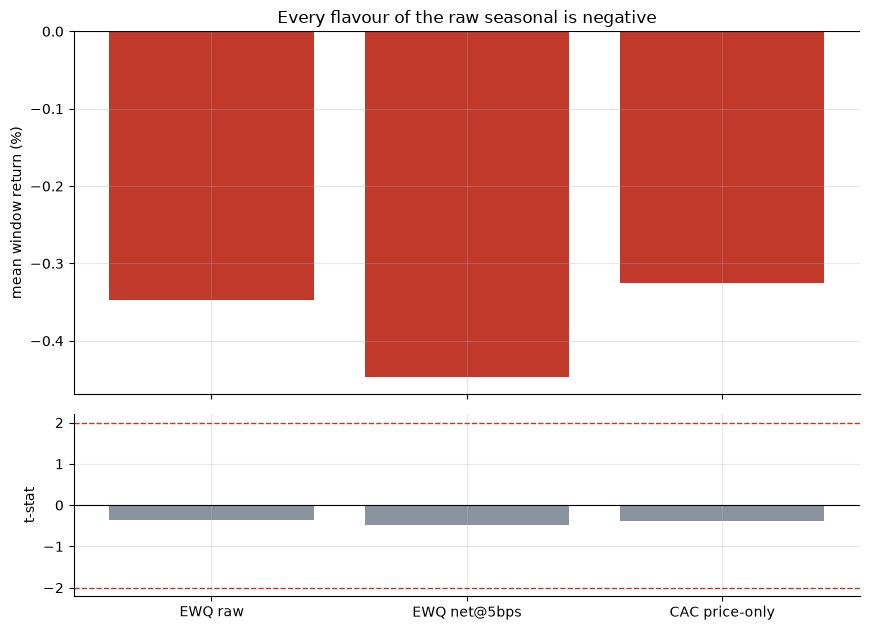

In [2]:
if HAVE_REAL:
    rows = []
    for lab, col in (('EWQ raw','raw_ret'), ('EWQ net@5bps','raw_net'), ('CAC price-only','cac_raw')):
        s = st.one_sample_t(INC[col].values); hr = st.hit_rate(INC[col].values)
        rows.append((lab, s['n'], s['mean']*100, s['t'], hr['k'], hr['n']))
        print(lab, 'n', s['n'], 'mean', round(s['mean']*100,3), 't', round(s['t'],3))
    labels=[r[0] for r in rows]; means=[r[2] for r in rows]; ts=[r[3] for r in rows]
else:
    labels=['EWQ raw','EWQ net@5bps','CAC price-only']
    means=[R['raw_mean'], R['raw_net_mean'], R['cac_mean']]
    ts=[R['raw_t'], R['raw_net_t'], R['cac_t']]
fig, (a1, a2) = plt.subplots(2, 1, figsize=(8.8, 6.4), sharex=True,
                             gridspec_kw={'height_ratios':[2,1]})
a1.bar(labels, means, color=[RED if m<0 else AMBER for m in means])
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean window return (%)')
a1.set_title('Every flavour of the raw seasonal is negative')
a2.bar(labels, ts, color=[RED if abs(t)>=2 else GREY for t in ts])
a2.axhline(2, ls='--', c=RED, lw=1); a2.axhline(-2, ls='--', c=RED, lw=1)
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('t-stat')
plt.tight_layout(); plt.show()

> 💡 In plain words: EWQ raw **-0.347%** (*t* = -0.37, hit 13/30 = 43%, Wilson [27%, 61%]); net **-0.447%**; CAC price-only **-0.325%**. Three independent measurements, all negative, none within a country mile of *t* = 2. **H1 rejected.**

### 4b · The decomposition — is any of it French? (the decisive cut)

The one measurement that can tell a *French* sentiment bump from ordinary summer beta: EWQ minus VGK over the same window, 2005→ (VGK coverage).

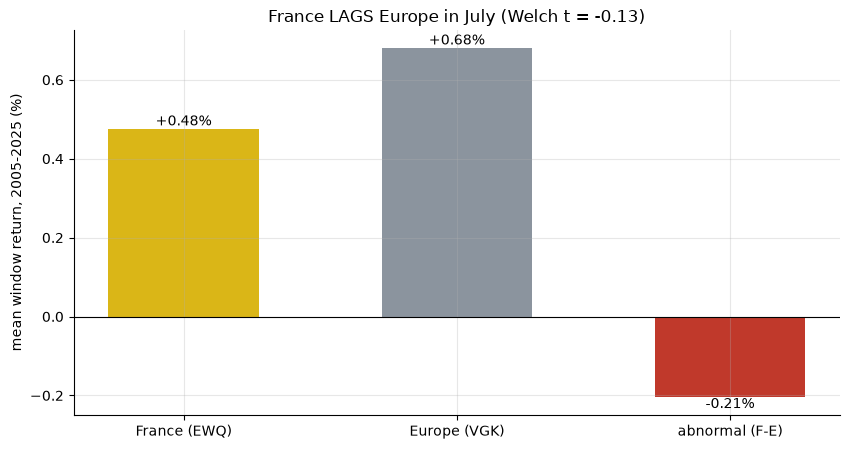

France +0.476%  Europe +0.681%  abnormal -0.205% (t=-0.777)  Welch -0.133


In [3]:
if HAVE_REAL:
    common = PRICES['EWQ'].index.intersection(PRICES['VGK'].index).sort_values()
    vgk_rets = []
    for _, r in SUB.iterrows():
        e, x = st._window_positions(common, r['grand_depart'], r['final_stage'])
        vgk_rets.append(PRICES['VGK'].loc[common[x]]/PRICES['VGK'].loc[common[e]]-1)
    s_ewq = st.one_sample_t(SUB['raw_ret'].values)
    s_vgk = st.one_sample_t(np.asarray(vgk_rets))
    s_ar = st.one_sample_t(SUB['ar'].values)
    welch = st.welch_t(SUB['raw_ret'].values, np.asarray(vgk_rets))
    ewq_m, vgk_m, ar_m, ar_t = s_ewq['mean']*100, s_vgk['mean']*100, s_ar['mean']*100, s_ar['t']
else:
    ewq_m, vgk_m, ar_m, ar_t, welch = R['ewq_sub_mean'], R['vgk_mean'], R['ar_mean'], R['ar_t'], R['welch']
fig, ax = plt.subplots(figsize=(8.6, 4.6))
bars = ax.bar(['France (EWQ)','Europe (VGK)','abnormal (F-E)'], [ewq_m, vgk_m, ar_m],
              color=[AMBER, GREY, RED], width=.55)
for b,v in zip(bars,[ewq_m,vgk_m,ar_m]):
    ax.annotate(f'{v:+.2f}%', (b.get_x()+b.get_width()/2, v), ha='center', va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('mean window return, 2005-2025 (%)')
ax.set_title(f'France LAGS Europe in July (Welch t = {welch:+.2f})')
plt.tight_layout(); plt.show()
print(f'France {ewq_m:+.3f}%  Europe {vgk_m:+.3f}%  abnormal {ar_m:+.3f}% (t={ar_t:+.3f})  Welch {welch:+.3f}')

> 💡 In plain words: over 2005→ France makes **+0.476%** and Europe makes **+0.681%**, so the France-specific abnormal is **-0.205%** (*t* = -0.78, hit 9/21), and the unpaired Welch *t* is -0.13. France does not beat Europe during the Tour — it slightly *lags*. **H2 rejected: the July softness is pan-European summer beta, not a home-crowd effect. This is the whole verdict in one chart.**

### 4c · The random-window placebo — is the Tour window unusual at all?

For each edition, redraw a random same-length window from elsewhere in EWQ's history, 20 seeds × 200 draws; compare the observed Tour mean to the null distribution of ordinary three-week windows.

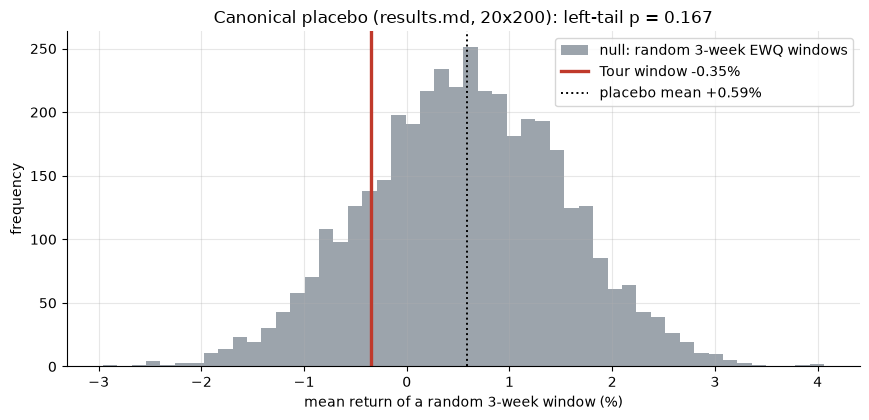

raw: obs -0.347% vs placebo +0.586% (sd 0.961%) left p=0.167, 83% of windows beat it
abnormal: obs -0.205% vs placebo -0.019% left p=0.247


In [4]:
rng = np.random.default_rng(732)
draws = rng.normal(R['pl_raw_mean'], R['pl_raw_sd'], 4000)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='null: random 3-week EWQ windows')
ax.axvline(R['raw_mean'], c=RED, lw=2.4, label=f"Tour window {R['raw_mean']:+.2f}%")
ax.axvline(R['pl_raw_mean'], c='k', ls=':', lw=1.4, label=f"placebo mean {R['pl_raw_mean']:+.2f}%")
ax.set_xlabel('mean return of a random 3-week window (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Canonical placebo (results.md, 20x200): left-tail p = {R["pl_raw_p"]:.3f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f"raw: obs {R['raw_mean']:+.3f}% vs placebo {R['pl_raw_mean']:+.3f}% (sd {R['pl_raw_sd']:.3f}%) "
      f"left p={R['pl_raw_p']:.3f}, {R['pl_raw_right']*100:.0f}% of windows beat it")
print(f"abnormal: obs {R['pl_ar_obs']:+.3f}% vs placebo {R['pl_ar_mean']:+.3f}% "
      f"left p={R['pl_ar_p']:.3f}")

> 💡 In plain words: the Tour window (-0.35%) is below the ordinary-window mean (+0.59%), but well inside the luck cloud — left-tail *p* = 0.167, and **83%** of random windows beat it. The abnormal cut is even more ordinary (*p* = 0.247). Not a special date on the calendar — just a below-median patch of summer.

### 4d · Event anatomy — is there any intra-window shape?

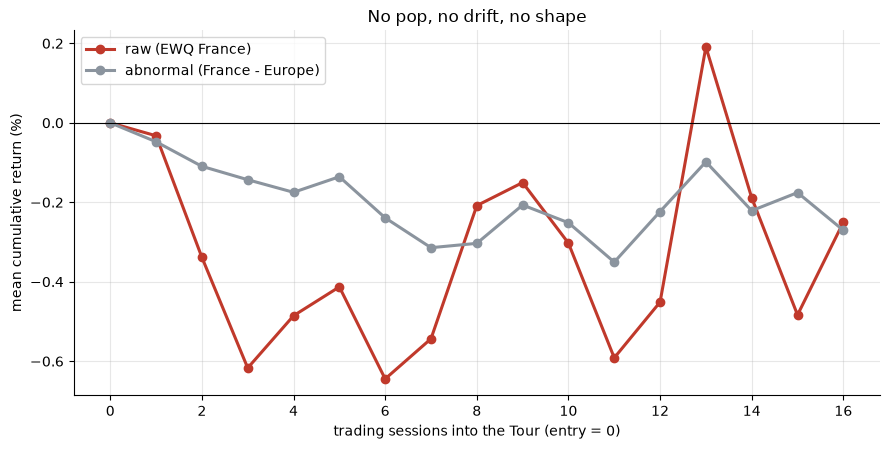

In [5]:
if HAVE_REAL:
    cp_raw = st.car_path(EV, PRICES, 'raw', 16); cp_ar = st.car_path(EV, PRICES, 'ar', 16)
    days=list(cp_raw.index); rs=list(cp_raw.values*100); as_=list(cp_ar.values*100)
else:
    days=sorted(R['car_raw']); rs=[R['car_raw'][k] for k in days]; as_=[R['car_ar'][k] for k in days]
fig, ax = plt.subplots(figsize=(9.0, 4.6))
ax.plot(days, rs, color=RED, lw=2.2, marker='o', label='raw (EWQ France)')
ax.plot(days, as_, color=GREY, lw=2.2, marker='o', label='abnormal (France - Europe)')
ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('trading sessions into the Tour (entry = 0)')
ax.set_ylabel('mean cumulative return (%)')
ax.set_title('No pop, no drift, no shape')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: a broadcast-driven national-mood mechanism predicts an early reaction that holds (like study 637's FOMC vol crush). Here the raw path dips to -0.49% by session 4 and wanders to -0.25% by the finish, with the France−Europe line flat-to-negative throughout. **H3 unsupported: this is drift-shaped noise, not an event reaction.**

### 4e · Robustness — the 2020 race-vs-calendar probe

2020 is the natural experiment: COVID-19 pushed the Tour out of July to Aug 29 → Sep 20. If any "effect" tracked the *calendar month* rather than the race, moving the window would change the answer. It doesn't.

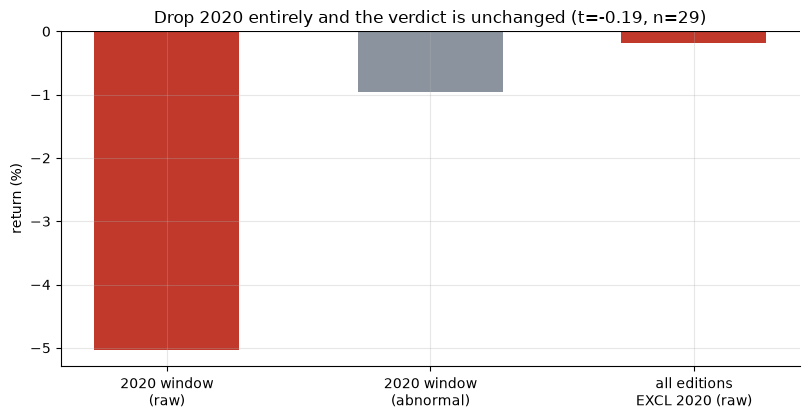

2020 raw -5.04% abnormal -0.96%; excl-2020 mean -0.185% t=-0.194


In [6]:
if HAVE_REAL:
    r20 = INC[INC['year']==2020].iloc[0]
    no20 = st.one_sample_t(INC[INC['year']!=2020]['raw_ret'].values)
    y20_raw, y20_ar, m_no20, t_no20, n_no20 = r20['raw_ret']*100, r20['ar']*100, no20['mean']*100, no20['t'], no20['n']
else:
    y20_raw, y20_ar, m_no20, t_no20, n_no20 = R['y2020_raw'], R['y2020_ar'], R['raw_no20_mean'], R['raw_no20_t'], R['raw_no20_n']
fig, ax = plt.subplots(figsize=(8.2, 4.3))
ax.bar(['2020 window\n(raw)','2020 window\n(abnormal)','all editions\nEXCL 2020 (raw)'],
       [y20_raw, y20_ar, m_no20], color=[RED, GREY, RED], width=.55)
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('return (%)')
ax.set_title(f'Drop 2020 entirely and the verdict is unchanged (t={t_no20:+.2f}, n={n_no20})')
plt.tight_layout(); plt.show()
print(f'2020 raw {y20_raw:+.2f}% abnormal {y20_ar:+.2f}%; excl-2020 mean {m_no20:+.3f}% t={t_no20:+.3f}')

> 💡 In plain words: 2020's Aug/Sep window (raw **-5.04%**) is just a bad market month, the worst single edition — and dropping it entirely leaves the raw seasonal at -0.185% (*t* = -0.19, n = 29). Nothing tracks the calendar *or* the race, because there is nothing to track.

### 4f · Faithful-engine & power control

Synthetic paired (France, Europe) log-return world (ρ ≈ 0.85, like a single-country ETF vs its regional benchmark), a scheduled annual window, TUNABLE planted per-day bump. Null (bump = 0) checked over **20 seeds**.

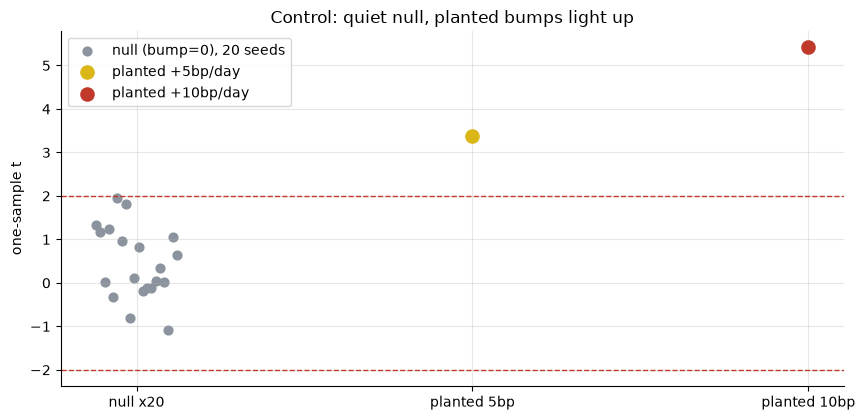

null mean t=+0.44 (sd 0.83), |t|>=2 in 0/20
planted 5bp t=+3.38  10bp t=+5.41


In [7]:
null_ts = np.array([st.synthetic_detect(bump=0.0, seed=732+s)['t'] for s in range(20)])
p5 = st.synthetic_detect(bump=0.0005, seed=732)
p10 = st.synthetic_detect(bump=0.0010, seed=732)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20)+np.linspace(-.12,.12,20), null_ts, color=GREY, s=40, label='null (bump=0), 20 seeds')
ax.scatter([1],[p5['t']], color=AMBER, s=90, zorder=5, label='planted +5bp/day')
ax.scatter([2],[p10['t']], color=RED, s=90, zorder=5, label='planted +10bp/day')
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1)
ax.set_xticks([0,1,2]); ax.set_xticklabels(['null x20','planted 5bp','planted 10bp'])
ax.set_ylabel('one-sample t'); ax.set_title('Control: quiet null, planted bumps light up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null mean t={null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), |t|>=2 in {(abs(null_ts)>=2).sum()}/20')
print(f'planted 5bp t={p5["t"]:+.2f}  10bp t={p10["t"]:+.2f}')

> 💡 In plain words: across 20 null seeds the detector averages t = +0.44 (sd 0.83) and fires at |t| ≥ 2 in 0/20 seeds; a planted +5 bp/day bump reads t = 3.38, +10 bp/day reads t = 5.41. The machinery detects a real seasonal cleanly — the real-tape emptiness is the tape's, not the detector's. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — raw -0.347% (*t* = -0.37), abnormal -0.205% (*t* = -0.78), CAC price-only -0.325% — three measurements, all mildly *negative*, hit rate 13/30 below a coin flip, and indistinguishable from an ordinary three weeks (placebo *p* = 0.167). No intra-window shape. Nothing at any bar, in either direction.
- **Tradability `MIRAGE`** — the seasonal is negative before costs and -0.447% after; there is simply no positive edge to trade. "Buy French stocks during the Tour" is a systematic small loss.
- **France-specific? `NOT SUPPORTED`** — France +0.476% vs Europe +0.681% (2005→), Welch *t* = -0.13; France lags Europe in July. The mild softness is ordinary pan-European summer beta — the folklore mis-attributes a region-wide, calendar-driven non-event to a bike race.

## 6 · Going further

- **The general lesson: a clean null is still a result.** No surprise, no information lag, a date fixed a year ahead, 30 independent events, and a healthy-power detector — the ideal conditions to *find* an effect if one existed. The premise still collapsed, because a raw July seasonal is fighting the documented "Sell in May" summer (Bouman & Jacobsen 2002) and has no France-specific component once Europe is netted out.
- **A more powerful test would go narrower.** French tourism / leisure / consumer-discretionary sub-indices (where a genuine summer-holiday mood would actually spend), or intraday data around the Champs-Élysées finale, would be the natural sequel — but they'd need to clear a *net, placebo-surviving* bar this broad-index test misses by a mile.
- **Dedup map:** [708-eurovision-effect](../../708-eurovision-effect/) (same national-mood folklore, but a *surprise* result with a real lag, across a per-country panel), [235-world-cup-effect](../../235-world-cup-effect/) (the real Edmans elimination-shock mechanism), [158-super-bowl](../../158-super-bowl/) and [709-world-series-effect](../../709-world-series-effect/) (US single-sport indicators). None test a single-country *calendar-window* sports seasonal against its regional benchmark — the summer-beta decomposition that decides this one is this study's own contribution.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*